# Feature Engineering — Tree-Optimized Feature Engineering
## Jianhui: XGBoost + SMOTE Training Pipeline

**Objective:** implement the feature candidates supported by the independent
EDA and prepare the leakage-controlled XGBoost + SMOTE training pipeline.
This notebook is the single point of truth for turning EDA's findings into
a model-ready feature matrix — it does not re-derive which features to use;
it reads that decision directly from `eda_feature_candidates.json` so the
EDA and Feature Engineering stages cannot silently drift apart.

**Validated candidates** (from EDA, Evidence Strength noted where relevant)
- `amt` and `amt_log` — Strong (near-100x fraud-rate lift above $500)
- merchant `category` → leakage-controlled target encoding — Strong (11.3x
  fraud-rate spread across categories)
- customer–merchant Haversine `distance_km` — Weak / retained only as an
  interaction candidate, not a validated standalone predictor
- `trans_hour`, `day_of_week`, `is_weekend` — Strong (hour) / Moderate (day)
- `city_pop` — Weak / retained only as an interaction candidate
- `age` and `gender` — Moderate, primarily for fairness monitoring rather
  than raw predictive strength

**Leakage-control rule and why it matters:** split into train/validation/test
*before* any target-dependent transformation. If category target-encoding
were fit on the full dataset first, every row's encoded value would
partially reflect its own label (directly, for training rows; indirectly,
through the category's overall rate, for validation/test rows) — inflating
validation and test performance in a way that would not hold on genuinely
new data. Training category encoding therefore uses out-of-fold values
(Section 4); validation/test are transformed using a mapping fitted on
training data only; SMOTE is applied only to training data (Section 6).

In [1]:
# ============================================================
# Install required packages
# ============================================================
%pip install -q -U \
    "boto3" \
    "botocore" \
    "mlflow==3.15.1" \
    "mlflow-skinny==3.15.1" \
    "mlflow-tracing==3.15.1" \
    "sagemaker-mlflow==0.5.0" \
    "imbalanced-learn" \
    "xgboost" \
    "pyarrow"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# Configuration, S3/local fallback, MLflow
# ============================================================
from pathlib import Path
import os
import json
import warnings
import boto3
from urllib.parse import urlparse

# ============================================================
# Project storage configuration
# Declare ONE S3 project root and ONE local project root.
# Filenames are declared separately and joined only when needed.
# ============================================================

S3_BUCKET_URI = os.getenv(
    "TEAM04_S3_BUCKET_URI",
    "s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/"
).rstrip("/") + "/"

LOCAL_DATA_DIR = Path(
    os.getenv("TEAM04_LOCAL_DATA_DIR", "./data")
)

# ---- Filenames: no filenames are embedded in S3 directory URIs ----
DATA_FILENAME = os.getenv(
    "TEAM04_FRAUD_TRAIN_FILENAME",
    "fraudTrain.csv"
)

EDA_FEATURE_CONFIG_FILENAME = "eda_feature_candidates.json"
FAIRNESS_BASELINE_FILENAME = "fairness_baselines.csv"
FE_OUTPUT_FILENAME = "feature_engineered_model_input.parquet"
FE_CONFIG_FILENAME = "feature_engineering_manifest.json"
MODELA_RESULTS_FILENAME = "model_a_baseline_results.json"
MODELA_FILENAME = "model_a_xgboost_baseline.json"

# ---- S3 directories derived from the single project root ----
S3_RAW_URI = S3_BUCKET_URI + "raw/"
S3_EDA_OUTPUT_URI = S3_BUCKET_URI + "processed/eda/"
S3_FE_OUTPUT_URI = S3_BUCKET_URI + "processed/feature_engineering/"
S3_MODELA_OUTPUT_URI = S3_BUCKET_URI + "processed/modela_baseline/"

# ---- Local directories mirror the S3 structure ----
LOCAL_RAW_DIR = LOCAL_DATA_DIR / "raw"
LOCAL_EDA_OUTPUT_DIR = LOCAL_DATA_DIR / "eda"
LOCAL_FE_OUTPUT_DIR = LOCAL_DATA_DIR / "feature_engineering"
LOCAL_MODELA_OUTPUT_DIR = LOCAL_DATA_DIR / "modela_baseline"

for _p in [
    LOCAL_RAW_DIR,
    LOCAL_EDA_OUTPUT_DIR,
    LOCAL_FE_OUTPUT_DIR,
    LOCAL_MODELA_OUTPUT_DIR,
]:
    _p.mkdir(parents=True, exist_ok=True)


def s3_join(prefix, *parts):
    """Safely join an S3 URI/prefix with one or more path components."""
    return prefix.rstrip("/") + "/" + "/".join(
        str(part).strip("/") for part in parts
    )


def parse_s3_uri(uri):
    p = urlparse(uri)
    if p.scheme != "s3" or not p.netloc:
        raise ValueError(f"Invalid S3 URI: {uri}")
    return p.netloc, p.path.lstrip("/")


def download_s3_to_local(s3_uri, local_path):
    """Try S3 first. If it fails, use an existing local file as failover."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        boto3.client("s3").download_file(bucket, key, str(local_path))
        print(f"✓ Loaded from S3: {s3_uri}")
        return local_path
    except Exception as exc:
        if local_path.exists():
            print(f"⚠ S3 unavailable; using local failover: {local_path}")
            print(f"  S3 error: {type(exc).__name__}: {exc}")
            return local_path

        raise RuntimeError(
            f"S3 load failed and local failover does not exist: {local_path}\n"
            f"S3 URI: {s3_uri}\n"
            f"Original error: {type(exc).__name__}: {exc}"
        ) from exc


def upload_local_to_s3(local_path, s3_uri):
    """Best-effort S3 upload. Local output remains the failover copy."""
    local_path = Path(local_path)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        boto3.client("s3").upload_file(str(local_path), bucket, key)
        print(f"✓ Saved to S3: {s3_uri}")
        return True
    except Exception as exc:
        print(f"⚠ S3 upload failed; local output retained: {local_path}")
        print(f"  S3 error: {type(exc).__name__}: {exc}")
        return False


def load_json_s3_or_local(s3_uri, local_path):
    local_path = download_s3_to_local(s3_uri, local_path)
    with open(local_path, "r", encoding="utf-8") as f:
        return json.load(f)


# ---  Environment Setup & MLflow Initialization ---
import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import mlflow

from mlflow_utils import initialize_mlflow

warnings.filterwarnings("ignore")

# Run-specific MLflow configuration
STUDENT_ID = "S402"
EXPERIMENT_NAME = "ITI113/team04/ModelA"

# Initialize MLflow and generate a fresh UI link
MLFLOW_APP_ARN = initialize_mlflow(
    student_id=STUDENT_ID,
    experiment_name=EXPERIMENT_NAME
)

print(f"MLflow App ARN: {MLFLOW_APP_ARN}")
print(f"Student ID: {STUDENT_ID}")
print(f"Experiment: {EXPERIMENT_NAME}")

# ---- Derived file paths ----
DATA_S3_URI = s3_join(S3_RAW_URI, DATA_FILENAME)
LOCAL_DATA_PATH = LOCAL_RAW_DIR / DATA_FILENAME

LOCAL_EDA_CONFIG_PATH = LOCAL_EDA_OUTPUT_DIR / EDA_FEATURE_CONFIG_FILENAME
LOCAL_FAIRNESS_PATH = LOCAL_EDA_OUTPUT_DIR / FAIRNESS_BASELINE_FILENAME

LOCAL_FE_OUTPUT_PATH = LOCAL_FE_OUTPUT_DIR / FE_OUTPUT_FILENAME
LOCAL_FE_CONFIG_PATH = LOCAL_FE_OUTPUT_DIR / FE_CONFIG_FILENAME

LOCAL_MODELA_RESULTS_PATH = LOCAL_MODELA_OUTPUT_DIR / MODELA_RESULTS_FILENAME
LOCAL_MODELA_PATH = LOCAL_MODELA_OUTPUT_DIR / MODELA_FILENAME

print("S3 project root:", S3_BUCKET_URI)
print("Local project root:", LOCAL_DATA_DIR)
print("S3 raw directory:", S3_RAW_URI)
print("S3 EDA output directory:", S3_EDA_OUTPUT_URI)
print("S3 Feature Engineering output directory:", S3_FE_OUTPUT_URI)
print("S3 MODELA output directory:", S3_MODELA_OUTPUT_URI)
print("Dataset filename:", DATA_FILENAME)
print("Dataset S3 URI:", DATA_S3_URI)
print("MLflow experiment:", EXPERIMENT_NAME)

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import mlflow

RANDOM_STATE = 42
TEST_SIZE = 0.20
SMOOTHING = 20
N_SPLITS_TE = 5
TARGET = "is_fraud"

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(EXPERIMENT_NAME)

print("Dataset S3 URI:", DATA_S3_URI)
print("EDA config S3 URI:", s3_join(S3_EDA_OUTPUT_URI, EDA_FEATURE_CONFIG_FILENAME))
print("Feature Engineering output S3 URI:", s3_join(S3_FE_OUTPUT_URI, FE_OUTPUT_FILENAME))


Initializing SageMaker MLflow connection for S402...
Target Experiment: ITI113/team04/ModelA
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow Tracking URI successfully set.
Fresh MLflow UI URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IjVMNEEyVSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDNML3QrYlZEZVB3RkZ3VEQyNG43cUhDb1diaEtsMnpVNEc1YlRnUWY3bzhBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGdlEwa3ZSMk5EY1ZCSFFuSm1RbWhtV1V4SVlrMDRUMUZ2VFVsUmR5dG9iVVpFZVhSQlNrUTViamhNTVcxb2RVTmhhVTQyTjI5NUwxaFVPRFZVTTFWMWR6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFSOVpFVjJISEducnZPWUVYUzltZlZnQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF6SFZMU

## 1. Load the Complete Dataset

This pipeline uses the complete dataset, consistent with the Jianhui EDA —
not a resample — since the feature-engineering decisions being implemented
here were validated against the full 1,296,675-row dataset, and testing them
on anything smaller risks introducing sampling artifacts the EDA didn't have.

The feature list itself is **not hard-coded** here. It is read directly from
`eda_feature_candidates.json`, the hand-off artifact EDA produces. This
means if EDA's feature selection changes in a future iteration, this
notebook picks up the change automatically on the next run rather than
silently using a stale, manually-copied list.

In [3]:
# ============================================================
# Load raw dataset and EDA hand-off — S3 first, local fallback
# ============================================================
df = pd.read_csv(download_s3_to_local(DATA_S3_URI, LOCAL_DATA_PATH))

EDA_CONFIG_S3_URI = s3_join(S3_EDA_OUTPUT_URI, EDA_FEATURE_CONFIG_FILENAME)
EDA_FEATURE_CONFIG = load_json_s3_or_local(EDA_CONFIG_S3_URI, LOCAL_EDA_CONFIG_PATH)

SELECTED_FEATURES = EDA_FEATURE_CONFIG["selected_features"]
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("EDA-selected features:")
print(SELECTED_FEATURES)


✓ Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/raw/fraudTrain.csv
✓ Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/eda/eda_feature_candidates.json
Shape: 1,296,675 rows x 23 columns
EDA-selected features:
['amt', 'amt_log', 'category_te', 'distance_km', 'distance_log', 'city_pop', 'trans_hour', 'day_of_week', 'is_weekend', 'age', 'gender_binary']


**Finding:** the dataset loads at 1,296,675 rows × 23 columns — matching
EDA's confirmed volume exactly, a first check that this notebook and EDA are
reading the same underlying data. The EDA hand-off resolves to 11 selected
features (`amt`, `amt_log`, `category_te`, `distance_km`, `distance_log`,
`city_pop`, `trans_hour`, `day_of_week`, `is_weekend`, `age`,
`gender_binary`), matching the candidate list documented in EDA Section 11's
hypothesis-to-action table.

## 2. Non-Target-Dependent Feature Engineering

These features can be created before the split because they are computed
purely from each row's own raw fields (coordinates, timestamps, dates of
birth) — none of them use `is_fraud`, so computing them on the full dataset
before splitting introduces no leakage. This is the key distinction from
Section 4's category encoding, which *does* depend on the target and
therefore must wait until after the split.

In [4]:
# ============================================================
# Apply EDA-selected non-target-dependent transformations
# ============================================================
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

x = df.copy()
x["trans_date_trans_time"] = pd.to_datetime(x["trans_date_trans_time"], errors="coerce")
x["dob"] = pd.to_datetime(x["dob"], errors="coerce")

# Transformation library; which features are included is controlled by the EDA JSON.
if "trans_hour" in SELECTED_FEATURES:
    x["trans_hour"] = x["trans_date_trans_time"].dt.hour
if "day_of_week" in SELECTED_FEATURES:
    x["day_of_week"] = x["trans_date_trans_time"].dt.dayofweek
if "is_weekend" in SELECTED_FEATURES:
    x["is_weekend"] = (x["trans_date_trans_time"].dt.dayofweek >= 5).astype(int)
if "age" in SELECTED_FEATURES:
    x["age"] = x["trans_date_trans_time"].dt.year - x["dob"].dt.year
    before_birthday = (
        (x["trans_date_trans_time"].dt.month < x["dob"].dt.month) |
        ((x["trans_date_trans_time"].dt.month == x["dob"].dt.month) &
         (x["trans_date_trans_time"].dt.day < x["dob"].dt.day))
    )
    x["age"] -= before_birthday.fillna(False).astype(int)
if "distance_km" in SELECTED_FEATURES or "distance_log" in SELECTED_FEATURES:
    x["distance_km"] = haversine_distance(x["lat"], x["long"], x["merch_lat"], x["merch_long"])
if "distance_log" in SELECTED_FEATURES:
    x["distance_log"] = np.log1p(x["distance_km"].clip(lower=0))
if "amt_log" in SELECTED_FEATURES:
    x["amt_log"] = np.log1p(x["amt"].clip(lower=0))

# category_te is target-dependent and is intentionally represented by raw category here.
# Target encoding is fitted only after the modelling split below.
raw_feature_map = {
    "amt": "amt", "amt_log": "amt_log", "category_te": "category",
    "distance_km": "distance_km", "distance_log": "distance_log",
    "city_pop": "city_pop", "trans_hour": "trans_hour", "day_of_week": "day_of_week",
    "is_weekend": "is_weekend", "age": "age", "gender_binary": "gender"
}

missing_requested = [f for f in SELECTED_FEATURES if f not in raw_feature_map]
if missing_requested:
    raise ValueError(f"EDA config contains unsupported feature(s): {missing_requested}")

RAW_MODEL_COLUMNS = [raw_feature_map[f] for f in SELECTED_FEATURES]
RAW_MODEL_COLUMNS = list(dict.fromkeys(RAW_MODEL_COLUMNS))
model_df = x[RAW_MODEL_COLUMNS + [TARGET]].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print(f"Rows used: {len(model_df):,}")
print(f"Fraud rate: {model_df[TARGET].mean()*100:.4f}%")
print("Raw/model hand-off columns:", RAW_MODEL_COLUMNS)

# Persist the non-target-dependent feature-engineered hand-off for Modelling.
model_df.to_parquet(LOCAL_FE_OUTPUT_PATH, index=False)
S3_FE_OUTPUT_URI_FULL = s3_join(S3_FE_OUTPUT_URI, FE_OUTPUT_FILENAME)
upload_local_to_s3(LOCAL_FE_OUTPUT_PATH, S3_FE_OUTPUT_URI_FULL)

FE_MANIFEST = {
    "schema_version": "1.0",
    "source_eda_config": EDA_CONFIG_S3_URI,
    "dataset_filename": DATA_FILENAME,
    "selected_features": SELECTED_FEATURES,
    "raw_model_columns": RAW_MODEL_COLUMNS,
    "target": TARGET,
    "target_dependent_features": EDA_FEATURE_CONFIG.get("target_dependent_features", []),
    "output_filename": FE_OUTPUT_FILENAME
}
with open(LOCAL_FE_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(FE_MANIFEST, f, indent=2)
upload_local_to_s3(LOCAL_FE_CONFIG_PATH, s3_join(S3_FE_OUTPUT_URI, FE_CONFIG_FILENAME))

print("✓ Feature-engineered hand-off saved locally:", LOCAL_FE_OUTPUT_PATH)
print("✓ Feature-engineered hand-off S3:", S3_FE_OUTPUT_URI_FULL)


Rows used: 1,296,675
Fraud rate: 0.5789%
Raw/model hand-off columns: ['amt', 'amt_log', 'category', 'distance_km', 'distance_log', 'city_pop', 'trans_hour', 'day_of_week', 'is_weekend', 'age', 'gender']
✓ Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/feature_engineering/feature_engineered_model_input.parquet
✓ Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/feature_engineering/feature_engineering_manifest.json
✓ Feature-engineered hand-off saved locally: data/feature_engineering/feature_engineered_model_input.parquet
✓ Feature-engineered hand-off S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/feature_engineering/feature_engineered_model_input.parquet


**Finding:** all 1,296,675 rows are retained through this transformation
step (no drops), and the fraud rate is unchanged at 0.5789% — confirming
the row-level transformations did not distort the target distribution. The
hand-off parquet and manifest are saved to S3 with a local fallback,
matching the project's shared storage convention.

## 3. Stratified Train / Validation / Test Split

A 60/20/20 stratified split is used, implemented as two sequential splits
(test carved off first, then the remainder divided into train/validation).
Stratification on `is_fraud` matters specifically because the fraud rate is
only 0.58% — a non-stratified random split could plausibly place a
meaningfully different fraud rate in each partition purely by chance, which
would make validation and test metrics harder to compare fairly against
each other.

**No target-dependent transformation is fitted before this split** — this is
the boundary Section 12's leakage checklist verifies at the end of the
notebook.

In [5]:
X = model_df.drop(columns=TARGET)
y = model_df[TARGET].astype(int)

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=RANDOM_STATE
)

print("Train:", len(X_train), f"fraud={y_train.mean()*100:.4f}%")
print("Valid:", len(X_valid), f"fraud={y_valid.mean()*100:.4f}%")
print("Test :", len(X_test),  f"fraud={y_test.mean()*100:.4f}%")

Train: 778005 fraud=0.5789%
Valid: 259335 fraud=0.5788%
Test : 259335 fraud=0.5788%


**Finding:** the split produces 778,005 / 259,335 / 259,335 rows for
train/validation/test, with fraud rates of 0.5789%, 0.5788%, and 0.5788%
respectively — differing by less than 0.0001 percentage points across all
three partitions. This confirms stratification worked as intended: none of
the three evaluation stages downstream is working from a partition with a
meaningfully different fraud prevalence than the others.

## 4. Leakage-Controlled Merchant Category Target Encoding

The category fraud rate is target-dependent, so it must not be calculated
from the entire dataset — doing so would let each row's own label leak into
its own encoded feature value.

**Why out-of-fold (OOF) encoding, specifically, rather than a single
train-then-apply mapping:** even restricting target encoding to the training
partition alone is not sufficient on its own. If every training row were
encoded using a category mean computed *including that same row*, each row
would still partially encode its own label — a milder but real version of
the same leakage problem, and one that specifically inflates *training* set
performance in a way that does not generalise. The fix used here: the
training partition is itself split into K folds; each fold's rows are
encoded using a mapping fit only on the *other* folds. Every training row's
encoded value is therefore computed without ever seeing that row's own
label. Validation and test rows use one mapping fit on the *complete*
training partition, since neither of those partitions is used to fit
anything.

**Why smoothing (`smoothing=20`):** some categories have far more
transactions than others (14 categories ranging from tens of thousands to
over 100,000 transactions in EDA Section 5). A raw per-category mean would
let low-count categories swing to extreme values from a handful of chance
fraud cases. Smoothing blends each category's raw mean toward the global
training fraud rate, weighted by how much data that category has — reducing
this to a Bayesian-style shrinkage estimate.

In [6]:
def fit_te_mapping(categories, target, smoothing=20):
    temp = pd.DataFrame({"category": categories, "target": target})
    global_mean = temp["target"].mean()

    stats = temp.groupby("category")["target"].agg(["count", "mean"])
    stats["encoded"] = (
        (stats["count"] * stats["mean"] + smoothing * global_mean) /
        (stats["count"] + smoothing)
    )
    return stats["encoded"].to_dict(), global_mean


def apply_te(categories, mapping, global_mean):
    return categories.map(mapping).fillna(global_mean).astype(float)


def make_oof_te(X_train, y_train, n_splits=5, smoothing=20, random_state=42):
    encoded = pd.Series(index=X_train.index, dtype=float)

    skf = StratifiedKFold(
        n_splits=n_splits, shuffle=True, random_state=random_state
    )

    for fit_pos, holdout_pos in skf.split(X_train, y_train):
        fit_idx = X_train.index[fit_pos]
        holdout_idx = X_train.index[holdout_pos]

        mapping, global_mean = fit_te_mapping(
            X_train.loc[fit_idx, "category"],
            y_train.loc[fit_idx],
            smoothing
        )

        encoded.loc[holdout_idx] = apply_te(
            X_train.loc[holdout_idx, "category"],
            mapping,
            global_mean
        )

    return encoded


X_train = X_train.copy()
X_valid = X_valid.copy()
X_test = X_test.copy()

if "category_te" in SELECTED_FEATURES:
    # OOF encoding for TRAIN rows
    X_train["category_te"] = make_oof_te(
        X_train, y_train,
        n_splits=N_SPLITS_TE,
        smoothing=SMOOTHING,
        random_state=RANDOM_STATE
    )

    # Final mapping fitted from TRAIN ONLY
    te_mapping, train_global_mean = fit_te_mapping(
        X_train["category"], y_train, SMOOTHING
    )

    # VALID and TEST transformed using TRAIN-ONLY mapping
    X_valid["category_te"] = apply_te(X_valid["category"], te_mapping, train_global_mean)
    X_test["category_te"] = apply_te(X_test["category"], te_mapping, train_global_mean)

    print("Target encoding completed.")
    print("Training global fraud rate:", train_global_mean)
    print("Categories learned:", len(te_mapping))
else:
    print("category_te not selected by EDA; target encoding skipped.")

Target encoding completed.
Training global fraud rate: 0.005789165879396662
Categories learned: 14


**Finding:** the encoder learns mappings for 14 categories against a
training global fraud rate of 0.5789%, consistent with EDA's own
category-level findings (fraud rate ranging 0.15%–1.76% across categories in
EDA Section 5). No categories are dropped or collapsed — all 14 raw
merchant categories receive a distinct encoded value.

## 5. Build the XGBoost Feature Matrix

XGBoost does not require standard scaling or normalisation — tree-based
splits operate on each feature's raw ordering, not its scale, so
standardising `amt` or `city_pop` would add a preprocessing step with no
benefit to this model family (unlike the linear/neural track, which does
need it).

`gender` is converted to binary form here rather than earlier, since it is
not target-dependent but is more naturally handled at final matrix-assembly
time alongside the other selected columns. The raw categorical `category`
field is replaced entirely by its leakage-controlled target encoding from
Section 4 — the raw string is not passed to the model.

In [7]:
def prepare_matrix(X):
    x = X.copy()
    feature_to_column = {
        "amt": "amt", "amt_log": "amt_log", "category_te": "category_te",
        "distance_km": "distance_km", "distance_log": "distance_log",
        "city_pop": "city_pop", "trans_hour": "trans_hour",
        "day_of_week": "day_of_week", "is_weekend": "is_weekend",
        "age": "age", "gender_binary": "gender_binary"
    }

    if "gender_binary" in SELECTED_FEATURES:
        x["gender_binary"] = x["gender"].map({"F": 0, "M": 1})

    selected_columns = [feature_to_column[f] for f in SELECTED_FEATURES]
    return x[selected_columns].apply(pd.to_numeric, errors="coerce")


X_train_model = prepare_matrix(X_train)
X_valid_model = prepare_matrix(X_valid)
X_test_model = prepare_matrix(X_test)

print("Feature columns:")
print(list(X_train_model.columns))
print("Train shape:", X_train_model.shape)

Feature columns:
['amt', 'amt_log', 'category_te', 'distance_km', 'distance_log', 'city_pop', 'trans_hour', 'day_of_week', 'is_weekend', 'age', 'gender_binary']
Train shape: (778005, 11)


**Finding:** the resulting feature matrix has exactly 11 columns, an exact
match to EDA's `selected_features` list with no additions, omissions, or
substitutions. This one-to-one match is itself a useful check — it confirms
the EDA→Feature Engineering hand-off worked as intended, with no silent
feature drift between what EDA validated and what the model actually
receives.

## 6. SMOTE — Training Data Only

**What SMOTE does:** rather than simply duplicating existing minority-class
(fraud) rows, SMOTE generates synthetic fraud examples by interpolating
between each real fraud transaction and its nearest fraud neighbours in
feature space. This gives the model more minority-class examples to learn
from than naive duplication would, without the model simply memorising
repeated identical rows.

**Why only `X_train`:** SMOTE is a training-time technique for helping the
model learn from more balanced classes — it is not a description of the
real world. Applying it to validation or test data would evaluate the model
against a fraud rate that does not exist in production, making the
evaluation metrics meaningless as an estimate of real-world performance.
Validation and test therefore keep the natural, untouched fraud
distribution throughout this notebook.

**Why `sampling_strategy=0.20` rather than full 50/50 balancing:** fully
balancing the training set to 50% fraud is a common default, but it can
push the model to over-predict fraud once it sees production-like data at
the true ~0.58% rate — the model effectively over-learns "fraud is common."
Partial rebalancing to 20% is a more conservative middle ground: it gives
the model substantially more signal to learn the minority class pattern
without distorting the decision boundary as aggressively as full balancing
would. This choice interacts directly with the calibration issue discussed
in Section 8 — worth reading together.

In [8]:
print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(
    sampling_strategy=0.20,
    random_state=RANDOM_STATE,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_model, y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())
print(f"Training fraud rate after SMOTE: {np.mean(y_train_smote)*100:.2f}%")

print("\nValidation fraud rate:", f"{y_valid.mean()*100:.4f}%")
print("Test fraud rate:", f"{y_test.mean()*100:.4f}%")

Before SMOTE:
is_fraud
0    773501
1      4504
Name: count, dtype: int64

After SMOTE:
is_fraud
0    773501
1    154700
Name: count, dtype: int64
Training fraud rate after SMOTE: 16.67%

Validation fraud rate: 0.5788%
Test fraud rate: 0.5788%


**Finding:** before SMOTE, the training fold has 773,501 legitimate vs.
4,504 fraud transactions. After SMOTE, fraud is oversampled to 154,700
(150,196 synthetic examples added), bringing the training fraud rate to
16.67% — well above the natural ~0.58% rate, exactly as intended by the
`sampling_strategy=0.20` setting. Validation (0.5788%) and test (0.5788%)
remain completely untouched, confirming the partition boundary held.

## 7. Baseline XGBoost

This is a deliberately **un-tuned baseline** for Feature Engineering — the hyperparameters
below (`n_estimators=300`, `max_depth=6`, `learning_rate=0.05`,
`subsample`/`colsample_bytree=0.8`) are reasonable, moderate-complexity
defaults, not the result of a search. Hyperparameter optimisation and final
threshold selection are treated as a separate, later stage so that this
milestone's numbers represent a clear, reproducible starting point to tune
against — not a result already shaped by tuning decisions.

`eval_metric="aucpr"` (area under the precision-recall curve) is used rather
than the default `logloss`, since AUCPR is what Section 8 explains is the
more informative metric for a problem this imbalanced — optimising the
training objective and the evaluation focus consistently.

In [9]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote,
    eval_set=[(X_valid_model, y_valid)],
    verbose=False
)

print("XGBoost baseline training completed.")

XGBoost baseline training completed.


**Finding:** training completes without error on the SMOTE-resampled
training fold. No validation-based early stopping is configured at this
stage — `eval_set` is passed for monitoring only, not to halt training
early — consistent with this being an intentionally simple, un-tuned
baseline.

## 8. Validation Evaluation

**Why PR-AUC is emphasised over ROC-AUC specifically for this problem:**
ROC-AUC is computed against the true-negative rate, and with legitimate
transactions outnumbering fraud roughly 172-to-1, a model can score a very
high ROC-AUC while still being practically unusable — true negatives are so
abundant that the false-positive rate barely moves even when the model
makes many mistakes in absolute terms. PR-AUC, by contrast, is computed only
from precision and recall on the positive (fraud) class, making it far more
sensitive to exactly the kind of errors that matter operationally here.
Precision, recall, and F1 are also reported at a fixed 0.50 threshold as a
reference point, ahead of the proper threshold selection in Section 10.

In [10]:
valid_prob = xgb_model.predict_proba(X_valid_model)[:, 1]
valid_pred = (valid_prob >= 0.50).astype(int)

valid_metrics = {
    "PR-AUC": average_precision_score(y_valid, valid_prob),
    "ROC-AUC": roc_auc_score(y_valid, valid_prob),
    "Precision": precision_score(y_valid, valid_pred, zero_division=0),
    "Recall": recall_score(y_valid, valid_pred, zero_division=0),
    "F1": f1_score(y_valid, valid_pred, zero_division=0),
}

display(pd.DataFrame(
    valid_metrics.items(),
    columns=["Metric", "Validation Score"]
))

print("Confusion matrix:")
print(confusion_matrix(y_valid, valid_pred))

,Metric,Validation Score
0,PR-AUC,0.832986
1,ROC-AUC,0.989561
2,Precision,0.160191
3,Recall,0.917388
4,F1,0.272754


Confusion matrix:
[[250615   7219]
 [   124   1377]]


**Finding — and why precision looks alarmingly low here.** At the default
0.50 threshold: PR-AUC 0.833 and ROC-AUC 0.990 both look strong, but
Precision is only **16.0%** (F1 0.273), with the confusion matrix showing
7,219 false positives against only 1,377 true positives.

This is not evidence of a weak model — it is a direct, expected consequence
of the SMOTE choice in Section 6. The model was trained on data where fraud
makes up 16.67% of transactions, so a 0.50 probability threshold reflects
what "more likely fraud than not" means *in that training distribution*.
Evaluated against validation data's true ~0.58% fraud rate, that same
threshold is far too permissive — it flags many legitimate transactions
that only look risky relative to the artificially fraud-heavy training mix.
The strong PR-AUC (which is threshold-independent, based on ranking rather
than a cutoff) confirms the model has genuinely learned to separate the
classes; the poor precision at 0.50 is a **calibration** problem, not a
**discrimination** problem. This is precisely what Section 10's threshold
sweep exists to correct.

## 9. Feature Importance

This is an initial model diagnostic using XGBoost's built-in importance
score — useful as a fast sanity check, but it reflects a single un-tuned
baseline model and should not be treated as a final ranking of feature
value. SHAP will be used later for the explainability component, which can
show per-prediction attribution and interaction effects that a single
importance score cannot.

,importance
amt,0.387850
amt_log,0.219030
category_te,0.110605
is_weekend,0.095430
gender_binary,0.051567
trans_hour,0.047732
day_of_week,0.039597
age,0.017928
city_pop,0.011636
distance_log,0.011164


<Axes: title={'center': 'Baseline XGBoost Feature Importance'}>

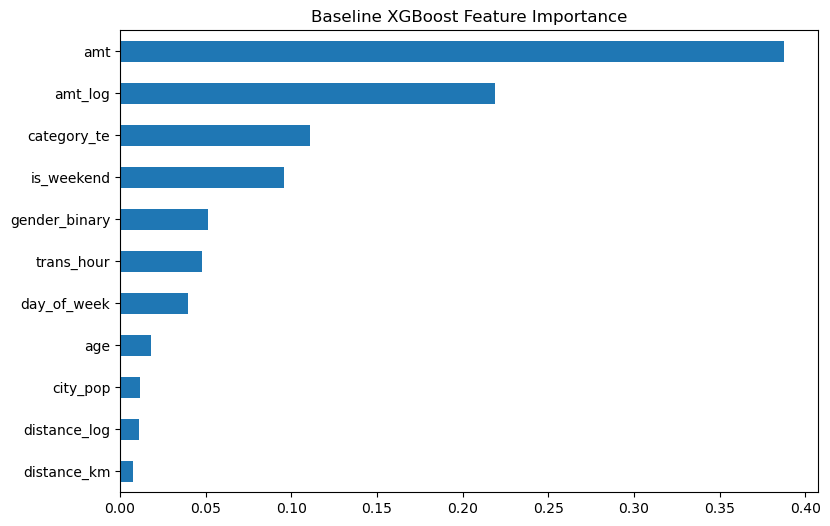

In [11]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train_model.columns
).sort_values(ascending=False)

display(importance.to_frame("importance"))

importance.sort_values().plot(
    kind="barh",
    figsize=(9, 6),
    title="Baseline XGBoost Feature Importance"
)

**Finding:** `amt` (0.388) and `amt_log` (0.219) dominate, together
accounting for over 60% of total importance — consistent with EDA's finding
of a near-100x fraud-rate lift by amount tier. `category_te` (0.111) ranks
third, also consistent with EDA. `distance_km` (0.007), `distance_log`
(0.011), and `city_pop` (0.012) rank lowest, consistent with EDA's finding
that neither showed meaningful univariate separation.

**Worth flagging as an open question rather than a resolved one:**
`is_weekend` (0.095) ranks *above* `trans_hour` (0.048) in this baseline,
despite EDA finding hour-of-day to be a much stronger univariate signal
(~5x fraud-rate lift at night) than day-of-week (~1.5x lift on the highest
day). A single importance score does not explain *why* this reversal
happens — it may reflect how XGBoost's histogram-based hour splits interact
with `amt`/`category_te` once those dominant features already account for
much of the pattern, or it may simply be baseline-model noise that
hyperparameter tuning changes. This is flagged here rather than explained
away, and is a good candidate question for the SHAP analysis to resolve
directly.

## 9a. Export Model-Ready Feature Engineering Outputs

The exact train/validation/test feature matrices and target vectors used in
this notebook — after target encoding and the split, but before SMOTE
(which is training-only and not part of the reusable feature set) — are
exported as a single `.joblib` file. This lets any downstream notebook
(hyperparameter tuning, governance/fairness auditing, model comparison)
load the identical, already-correctly-encoded data rather than re-deriving
target encoding independently, which risks producing a subtly different
result and losing the leakage guarantees established above.

In [12]:
# Export Model-Ready Feature Engineering Outputs

import os
import joblib

os.makedirs(LOCAL_FE_OUTPUT_DIR, exist_ok=True)

fe_output_path = (
    LOCAL_FE_OUTPUT_DIR /
    "feature_engineered_model_input.joblib"
)

fe_output = {
    "X_train_model": X_train_model,
    "X_valid_model": X_valid_model,
    "X_test_model": X_test_model,
    "y_train": y_train,
    "y_valid": y_valid,
    "y_test": y_test
}

joblib.dump(fe_output, fe_output_path)

print("Feature Engineering output saved:")
print(fe_output_path)

print("\nModel-ready shapes:")
print("X_train_model:", X_train_model.shape)
print("X_valid_model:", X_valid_model.shape)
print("X_test_model :", X_test_model.shape)
print("y_train      :", y_train.shape)
print("y_valid      :", y_valid.shape)
print("y_test       :", y_test.shape)

Feature Engineering output saved:
data/feature_engineering/feature_engineered_model_input.joblib

Model-ready shapes:
X_train_model: (778005, 11)
X_valid_model: (259335, 11)
X_test_model : (259335, 11)
y_train      : (778005,)
y_valid      : (259335,)
y_test       : (259335,)


## 10. Validation Threshold Analysis

Section 8 showed that the default 0.50 threshold is poorly calibrated for
this model, a direct consequence of training on SMOTE-rebalanced data. This
section searches for a better operating threshold to correct that.

The operating threshold is selected using the **validation set only**.
Candidate thresholds are evaluated using precision, recall, and F1. The
held-out test set is not used for threshold selection — using it here would
mean the "held-out" evaluation in Section 11 is no longer a genuinely
unseen estimate of performance.

,threshold,precision,recall,f1
18,0.95,0.884117,0.726849,0.797806
17,0.90,0.751894,0.793471,0.772123
16,0.85,0.613491,0.830113,0.705549
15,0.80,0.486312,0.852099,0.619221
14,0.75,0.388922,0.870087,0.537559
13,0.70,0.315065,0.884744,0.464661
12,0.65,0.257791,0.892738,0.400060
11,0.60,0.218659,0.904064,0.352147
10,0.55,0.186570,0.910726,0.309696
9,0.50,0.160191,0.917388,0.272754


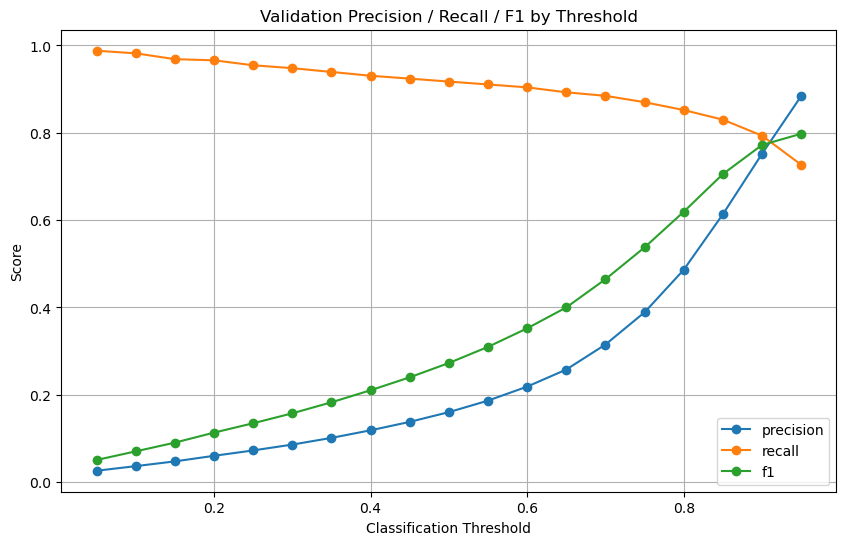

In [13]:
import matplotlib.pyplot as plt

# Select the operating threshold using VALIDATION only.

threshold_rows = []

for threshold in np.arange(0.05, 0.96, 0.05):
    pred = (valid_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred, zero_division=0),
        "f1": f1_score(y_valid, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.sort_values("f1", ascending=False))

threshold_df.plot(x="threshold", y=["precision", "recall", "f1"], marker="o", figsize=(10,6), title="Validation Precision / Recall / F1 by Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.grid(True)
plt.show()


In [14]:
# Select the threshold that maximises validation F1.

best_row = threshold_df.loc[threshold_df["f1"].idxmax()]
FINAL_THRESHOLD = float(best_row["threshold"])

print(f"Selected validation threshold: {FINAL_THRESHOLD:.2f}")
print(f"Validation Precision: {best_row['precision']:.4f}")
print(f"Validation Recall: {best_row['recall']:.4f}")
print(f"Validation F1: {best_row['f1']:.4f}")

assert 0.05 <= FINAL_THRESHOLD <= 0.95


Selected validation threshold: 0.95
Validation Precision: 0.8841
Validation Recall: 0.7268
Validation F1: 0.7978


**Finding:** F1 rises steadily as the threshold increases from 0.50 (F1
0.273) to 0.95 (F1 0.798), with precision climbing from 16% to 88% and
recall falling from 92% to 73%. The threshold sweep selects **0.95** as
optimal for this run.

**Limitation worth noting:** 0.95 is also the *highest* threshold included
in the search range (`0.05` to `0.95` in steps of `0.05`). When the best
result in a sweep lands exactly on the boundary of the range tested, that
is a signal the true optimum may lie beyond what was searched, not
necessarily at the edge by coincidence. A follow-up sweep extending to,
say, 0.99 in finer increments would confirm whether 0.95 is a genuine
interior optimum or whether F1 continues improving past it — worth doing
before treating 0.95 as final rather than provisional.

## 11. Final Held-Out Test Evaluation

The validation-selected threshold is frozen and applied **once** to the
held-out test set. This "look once" discipline matters because any
adjustment made after seeing test performance — even a small one — turns
the test set into a second validation set, and the resulting metric stops
being an honest estimate of performance on genuinely unseen data.

PR-AUC and ROC-AUC use continuous probabilities (threshold-independent);
precision, recall, and F1 use predictions generated with the frozen
threshold from Section 10.

In [15]:
# Apply the frozen validation threshold once to the held-out test set.

test_prob = xgb_model.predict_proba(X_test_model)[:, 1]
test_pred = (test_prob >= FINAL_THRESHOLD).astype(int)

test_metrics = {
    "PR-AUC": average_precision_score(y_test, test_prob),
    "ROC-AUC": roc_auc_score(y_test, test_prob),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
}
test_cm = confusion_matrix(y_test, test_pred)
display(pd.DataFrame(test_metrics.items(), columns=["Metric", "Test Score"]).round(4))
print(f"Final test threshold: {FINAL_THRESHOLD:.2f}")
print("Test confusion matrix:")
print(test_cm)
tn, fp, fn, tp = test_cm.ravel()
test_fpr = fp / (fp + tn) if (fp + tn) else 0.0
test_fnr = fn / (fn + tp) if (fn + tp) else 0.0
print(f"Test FPR: {test_fpr:.6f}")
print(f"Test FNR: {test_fnr:.6f}")


,Metric,Test Score
0,PR-AUC,0.8133
1,ROC-AUC,0.9904
2,Precision,0.8618
3,Recall,0.6982
4,F1,0.7714


Final test threshold: 0.95
Test confusion matrix:
[[257666    168]
 [   453   1048]]
Test FPR: 0.000652
Test FNR: 0.301799


**Finding:** at the frozen threshold of 0.95, test performance is PR-AUC
0.8133, ROC-AUC 0.9904, Precision 86.18%, Recall 69.82%, F1 0.7714 — closely
tracking the validation numbers from Section 10 (Precision 88.4%, Recall
72.7%, F1 0.798), which is itself a good sign: a large gap between
validation and test at the same threshold would suggest the threshold was
overfit to validation noise.

**Operational trade-off to name explicitly:** at this threshold, the model
misses **30.2%** of actual fraud (FNR) while keeping false alarms very low
(FPR 0.065% — 168 false positives out of 257,834 legitimate test
transactions). Whether this trade-off is the right one depends on the
relative cost of a missed fraud case versus a false alarm to the business,
which is a policy decision, not a purely statistical one — worth flagging
explicitly rather than treating "F1-optimal" as automatically "best."
Combined with Section 10's note that 0.95 sits at the edge of the searched
range, this test result should be read as a strong provisional baseline,
not a final, fully-optimised operating point.

## 11a. Comprehensive Feature-Engineering Manifest

A single structured JSON captures everything needed to reproduce or audit
this notebook's output without re-reading the code: the EDA contract this
run consumed, the target-encoding configuration, split sizes and fraud
rates, SMOTE parameters, the threshold-selection result, and final test
metrics. This is exported alongside the parquet/joblib data artifacts so
that any downstream notebook or reviewer has one canonical record of what
this pipeline actually did, rather than needing to infer it from cell
outputs scattered through the notebook.

In [16]:
# Comprehensive Feature-Engineering Manifest

feature_manifest = {
    "schema_version": "2.0",
    "pipeline": {
        "name": "Team04 Jianhui Feature Engineering",
        "stage": "FE",
        "source_eda_notebook": "EDA",
        "eda_contract_schema": EDA_FEATURE_CONFIG.get("schema_version"),
        "data_source": DATA_SOURCE if "DATA_SOURCE" in globals() else "S3/local fallback"
    },
    "eda_contract": {
        "selected_model_features": SELECTED_FEATURES,
        "selected_feature_count": len(SELECTED_FEATURES)
    },
    "target_encoding": {
        "smoothing": SMOOTHING,
        "folds": N_SPLITS_TE,
        "method": "OOF training encoding; training-only mapping for validation and test"
    },
    "split": {
        "train_rows": int(len(X_train_model)),
        "validation_rows": int(len(X_valid_model)),
        "test_rows": int(len(X_test_model)),
        "train_fraud_rate_percent": float(y_train.mean() * 100),
        "validation_fraud_rate_percent": float(y_valid.mean() * 100),
        "test_fraud_rate_percent": float(y_test.mean() * 100)
    },
    "smote": {
        "sampling_strategy": 0.20,
        "k_neighbors": 5,
        "random_state": RANDOM_STATE,
        "applied_to": "training data only",
        "resampled_training_rows": int(len(X_train_smote)),
        "resampled_fraud_rate_percent": float(np.mean(y_train_smote) * 100)
    },
    "xgboost": {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "random_state": RANDOM_STATE,
        "tree_method": "hist"
    },
    "validation": {
        "PR-AUC": float(valid_metrics["PR-AUC"]),
        "ROC-AUC": float(valid_metrics["ROC-AUC"]),
        "Precision_at_0.50": float(valid_metrics["Precision"]),
        "Recall_at_0.50": float(valid_metrics["Recall"]),
        "F1_at_0.50": float(valid_metrics["F1"]),
        "threshold_selection_method": "Maximum validation F1",
        "selected_threshold": float(FINAL_THRESHOLD),
        "selected_threshold_precision": float(best_row["precision"]),
        "selected_threshold_recall": float(best_row["recall"]),
        "selected_threshold_f1": float(best_row["f1"])
    },
    "test": {
        "threshold": float(FINAL_THRESHOLD),
        "PR-AUC": float(test_metrics["PR-AUC"]),
        "ROC-AUC": float(test_metrics["ROC-AUC"]),
        "Precision": float(test_metrics["Precision"]),
        "Recall": float(test_metrics["Recall"]),
        "F1": float(test_metrics["F1"]),
        "confusion_matrix": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
        "FPR": float(test_fpr),
        "FNR": float(test_fnr)
    },
    "mlflow": {
        "experiment_name": MLFLOW_EXPERIMENT if "MLFLOW_EXPERIMENT" in globals() else "ITI113/team04/ModelA",
        "run_name": "S402_FE"
    }
}

LOCAL_FE_MANIFEST_PATH = Path(LOCAL_FE_OUTPUT_DIR) / "feature_engineering_manifest.json"
with open(LOCAL_FE_MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(feature_manifest, f, indent=2, default=str)

print(f"Comprehensive manifest saved to: {LOCAL_FE_MANIFEST_PATH}")


Comprehensive manifest saved to: data/feature_engineering/feature_engineering_manifest.json


## 11b. MLflow Logging

This run's configuration, metrics, and artifacts are logged to the shared
MLflow experiment so that Feature Engineering's results are queryable and
comparable alongside every other stage of this pipeline (EDA, Model A,
and — once available — the governance/fairness audit), rather than living
only as static files.

In [17]:

if mlflow.active_run():
    mlflow.end_run()

RUN_NAME = f"{STUDENT_ID}_FE"

with mlflow.start_run(run_name=RUN_NAME) as run:
    mlflow.set_tags({
        "Course": "ITI113", "Semester": "26S1", "TeamId": "team04",
        "StudentId": STUDENT_ID, "ProjectName": "credit-card-fraud-detection",
        "CreatedByNotebook": "FeatureEngineering",   # ← fixed from "ModelA" while you're in here
        "PipelineStage": "FeatureEngineering",
    })
    mlflow.log_param("dataset_filename", DATA_FILENAME)
    mlflow.log_param("eda_config", EDA_CONFIG_S3_URI)
    mlflow.log_param("selected_feature_count", len(SELECTED_FEATURES))
    mlflow.log_param("selected_features", ",".join(SELECTED_FEATURES))
    mlflow.log_param("target_encoding_folds", N_SPLITS_TE)
    mlflow.log_param("target_encoding_smoothing", SMOOTHING)
    mlflow.log_param("output_rows", len(model_df))
    mlflow.log_param("output_columns", len(RAW_MODEL_COLUMNS))
    mlflow.log_artifact(str(LOCAL_FE_CONFIG_PATH), artifact_path="feature_engineering")
    mlflow.log_artifact(str(LOCAL_FE_OUTPUT_PATH), artifact_path="feature_engineering")
    mlflow.log_artifact(str(LOCAL_EDA_CONFIG_PATH), artifact_path="eda_outputs")
    mlflow.log_artifact(str(LOCAL_FAIRNESS_PATH), artifact_path="eda_outputs")

    print(f"✓ Feature Engineering MLflow run completed.")
    print(f"Run name: {RUN_NAME}")
    print(f"Run ID: {run.info.run_id}")

✓ Feature Engineering MLflow run completed.
Run name: S402_FE
Run ID: 631e4377ac7d4563af921f24a7e13ee0
🏃 View run S402_FE at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/4/runs/631e4377ac7d4563af921f24a7e13ee0
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/4


## 12. Feature Engineering Leakage-Control Checklist

- [x] Complete dataset used
- [x] Stratified train/validation/test split performed first
- [x] Merchant target encoding is target-dependent and therefore fitted after the split
- [x] Training category encoding uses out-of-fold values
- [x] Validation/test category encoding uses a training-only mapping
- [x] SMOTE is applied only to training data
- [x] Validation/test distributions remain untouched
- [x] Test set is not used for threshold selection
- [x] XGBoost is trained using the SMOTE-balanced training data

### Summary of findings

This baseline pipeline reproduces EDA's strongest signals directly in model
behaviour: `amt`/`amt_log` and `category_te` dominate feature importance,
consistent with the largest effects found in EDA. The default 0.50
threshold produces misleadingly poor precision (16%) — not because the
model is weak (PR-AUC 0.833 on validation), but because SMOTE's training-
time rebalancing to 16.67% fraud miscalibrates the default decision
boundary against the true ~0.58% rate; correcting for this via validation-
only threshold selection (Section 10) raises F1 from 0.273 to 0.798 on
validation and confirms consistently at 0.7714 on the held-out test set.
Two points are carried forward as open items rather than settled
conclusions: the selected threshold (0.95) sits at the edge of the range
searched and should be re-swept further before being treated as final, and
`is_weekend` outranking `trans_hour` in baseline feature importance
contradicts EDA's univariate finding and is flagged for the planned SHAP
analysis to resolve.

### Milestone deliverable

This notebook implements the validated feature candidates from Jianhui's
EDA and establishes the leakage-controlled **XGBoost + SMOTE** training
pipeline.